In [2]:
pip install Xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Users\hp\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [3]:
##Day 8
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier, plot_importance
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

sns.set_style("darkgrid")
os.makedirs('../models', exist_ok=True)

print("✅ All imports successful!")

✅ All imports successful!


In [26]:
# Cell 2 — Load all splits
X_train = pd.read_csv('../data/splits/X_train.csv')
y_train = pd.read_csv(
    '../data/splits/y_train.csv'
).squeeze()

X_test = pd.read_csv('../data/splits/X_test.csv')
y_test = pd.read_csv('../data/splits/y_test.csv').squeeze()

# Load baseline results to compare later
with open('../models/baseline_results.json', 'r') as f:
    baseline = json.load(f)

print("✅ Data loaded!")
print(f"Training samples: {len(X_train_smote):,}")
print(f"Test samples: {len(X_test):,}")
print(f"\nBaseline AUC-ROC to beat: {baseline['auc_roc']}")

✅ Data loaded!
Training samples: 227,845
Test samples: 56,962

Baseline AUC-ROC to beat: 0.9707


In [ ]:
# Cell 3 — Parameter explanation
print("""
=== XGBOOST KEY PARAMETERS ===

n_estimators = 300
→ Number of trees to build
→ More trees = more accurate but slower
→ Too many = overfitting

learning_rate = 0.05
→ How much each tree contributes
→ Lower = more careful learning
→ Lower learning_rate needs more n_estimators

max_depth = 6
→ How deep each tree can go
→ Deeper = learns more complex patterns
→ Too deep = overfitting

subsample = 0.8
→ Each tree uses 80% of training data
→ Prevents overfitting
→ Adds randomness = more robust

colsample_bytree = 0.8
→ Each tree uses 80% of features
→ Similar to Random Forest's feature sampling
→ Prevents any single feature dominating

scale_pos_weight = 99
→ Tells XGBoost fraud is 99x more important
→ Because fraud is 1% of data
→ Calculated as: legit_count / fraud_count

eval_metric = 'auc'
→ Monitor AUC-ROC during training
→ Helps detect overfitting early
""")

In [28]:
# Cell 4 — Calculate exact scale_pos_weight
from collections import Counter

original_dist = Counter(y_train)
print("distribution:", original_dist)

# Load original (before SMOTE) to calculate weight
y_train_original = pd.read_csv(
    '../data/splits/y_train.csv'
).squeeze()

legit_count = (y_train_original == 0).sum()
fraud_count = (y_train_original == 1).sum()

scale_pos_weight = legit_count / fraud_count

print(f"\nOriginal training data:")
print(f"Legit: {legit_count:,}")
print(f"Fraud: {fraud_count:,}")
print(f"\nscale_pos_weight = {legit_count} / {fraud_count}")
print(f"scale_pos_weight = {scale_pos_weight:.1f}")


distribution: Counter({0: 227451, 1: 394})

Original training data:
Legit: 227,451
Fraud: 394

scale_pos_weight = 227451 / 394
scale_pos_weight = 577.3


In [24]:
# Cell 5 — Basic XGBoost (Version 1)
print("Training XGBoost V1 (Basic)...")
print("This will take 2-3 minutes...\n")

xgb_v1 = XGBClassifier(
    n_estimators=100,          # start small
    learning_rate=0.1,         # default
    max_depth=6,               # default
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1                  # use all CPU cores
)

xgb_v1.fit(
    X_train_smote, y_train_smote,
    eval_set=[(X_test, y_test)],
    verbose=20    # print every 20 rounds
)

# Quick evaluation
y_pred_v1 = xgb_v1.predict(X_test)
y_prob_v1 = xgb_v1.predict_proba(X_test)[:, 1]
auc_v1 = roc_auc_score(y_test, y_prob_v1)

print(f"\n✅ XGBoost V1 trained!")
print(f"AUC-ROC: {auc_v1:.4f}")
print(f"Baseline was: {baseline['auc_roc']}")
print(f"Improvement: +{auc_v1 - baseline['auc_roc']:.4f}")

Training XGBoost V1 (Basic)...
This will take 2-3 minutes...

[0]	validation_0-auc:0.91967
[20]	validation_0-auc:0.95511
[40]	validation_0-auc:0.97081
[60]	validation_0-auc:0.96910
[80]	validation_0-auc:0.96896
[99]	validation_0-auc:0.96872

✅ XGBoost V1 trained!
AUC-ROC: 0.9687
Baseline was: 0.9707
Improvement: +-0.0020


In [30]:
# Cell 6 — Optimized XGBoost (Version 2)
print("Training XGBoost V2 (Optimized)...")
print("This will take 4-5 minutes...\n")

xgb_v2 = XGBClassifier(
    # Core parameters
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,

    # Regularization (prevents overfitting)
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=1,
    gamma=0,

    # Imbalance handling
    scale_pos_weight=scale_pos_weight,

    # Technical
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

xgb_v2.fit(
    X_train_smote, y_train_smote,
    eval_set=[(X_test, y_test)],
    verbose=50    # print every 50 rounds
)

# Evaluate
y_pred_v2 = xgb_v2.predict(X_test)
y_prob_v2 = xgb_v2.predict_proba(X_test)[:, 1]
auc_v2 = roc_auc_score(y_test, y_prob_v2)

print(f"\n✅ XGBoost V2 trained!")
print(f"AUC-ROC: {auc_v2:.4f}")
print(f"V1 was: {auc_v1:.4f}")
print(f"Baseline was: {baseline['auc_roc']}")

Training XGBoost V2 (Optimized)...
This will take 4-5 minutes...

[0]	validation_0-auc:0.91519
[50]	validation_0-auc:0.98040
[100]	validation_0-auc:0.97926
[150]	validation_0-auc:0.97909
[200]	validation_0-auc:0.98080
[250]	validation_0-auc:0.98189
[299]	validation_0-auc:0.98165

✅ XGBoost V2 trained!
AUC-ROC: 0.9817
V1 was: 0.9687
Baseline was: 0.9707


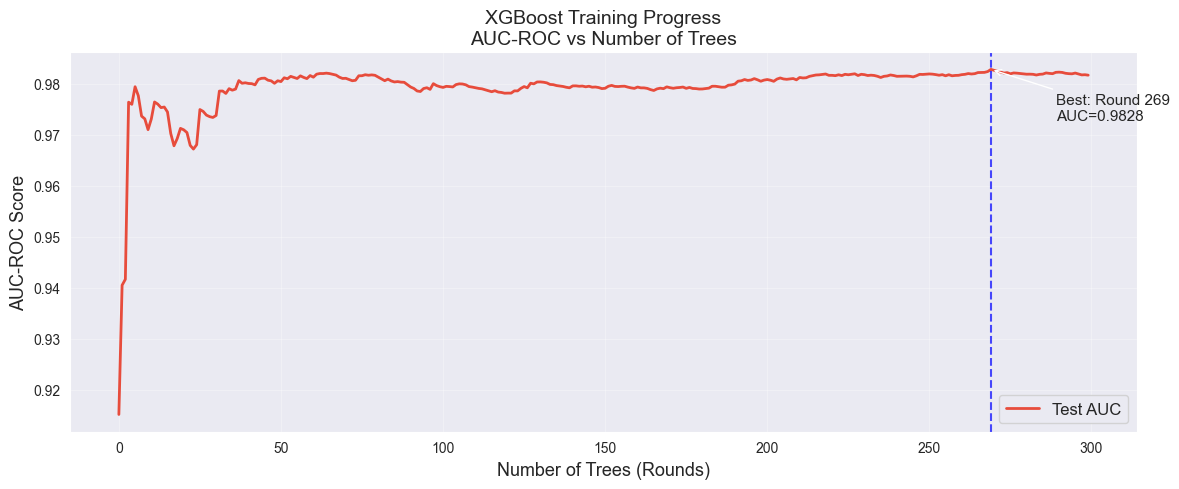

Best round: 269
Best AUC: 0.9828


In [31]:
# Cell 7 — Plot AUC during training
# This shows if model is learning or overfitting

results_v2 = xgb_v2.evals_result()

plt.figure(figsize=(12, 5))

plt.plot(results_v2['validation_0']['auc'],
         color='#e74c3c', linewidth=2,
         label='Test AUC')

plt.xlabel('Number of Trees (Rounds)', fontsize=13)
plt.ylabel('AUC-ROC Score', fontsize=13)
plt.title('XGBoost Training Progress\n'
          'AUC-ROC vs Number of Trees',
          fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# Mark best point
best_round = np.argmax(results_v2['validation_0']['auc'])
best_auc = max(results_v2['validation_0']['auc'])
plt.axvline(x=best_round, color='blue',
            linestyle='--', alpha=0.7)
plt.annotate(f'Best: Round {best_round}\nAUC={best_auc:.4f}',
             xy=(best_round, best_auc),
             xytext=(best_round + 20, best_auc - 0.01),
             fontsize=11,
             arrowprops=dict(arrowstyle='->'))

plt.tight_layout()
plt.savefig('../data/xgb_training_progress.png')
plt.show()

print(f"Best round: {best_round}")
print(f"Best AUC: {best_auc:.4f}")

In [32]:
# Cell 8 — Complete evaluation
print("=" * 50)
print("XGBOOST V2 — FULL EVALUATION REPORT")
print("=" * 50)

print("\n=== CLASSIFICATION REPORT ===\n")
print(classification_report(
    y_test, y_pred_v2,
    target_names=['Legit', 'Fraud']
))

print(f"=== KEY METRICS ===")
auc = roc_auc_score(y_test, y_prob_v2)
avg_prec = average_precision_score(y_test, y_prob_v2)
print(f"AUC-ROC:           {auc:.4f}")
print(f"Average Precision: {avg_prec:.4f}")

XGBOOST V2 — FULL EVALUATION REPORT

=== CLASSIFICATION REPORT ===

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.85      0.84      0.85        98

    accuracy                           1.00     56962
   macro avg       0.93      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962

=== KEY METRICS ===
AUC-ROC:           0.9817
Average Precision: 0.8800


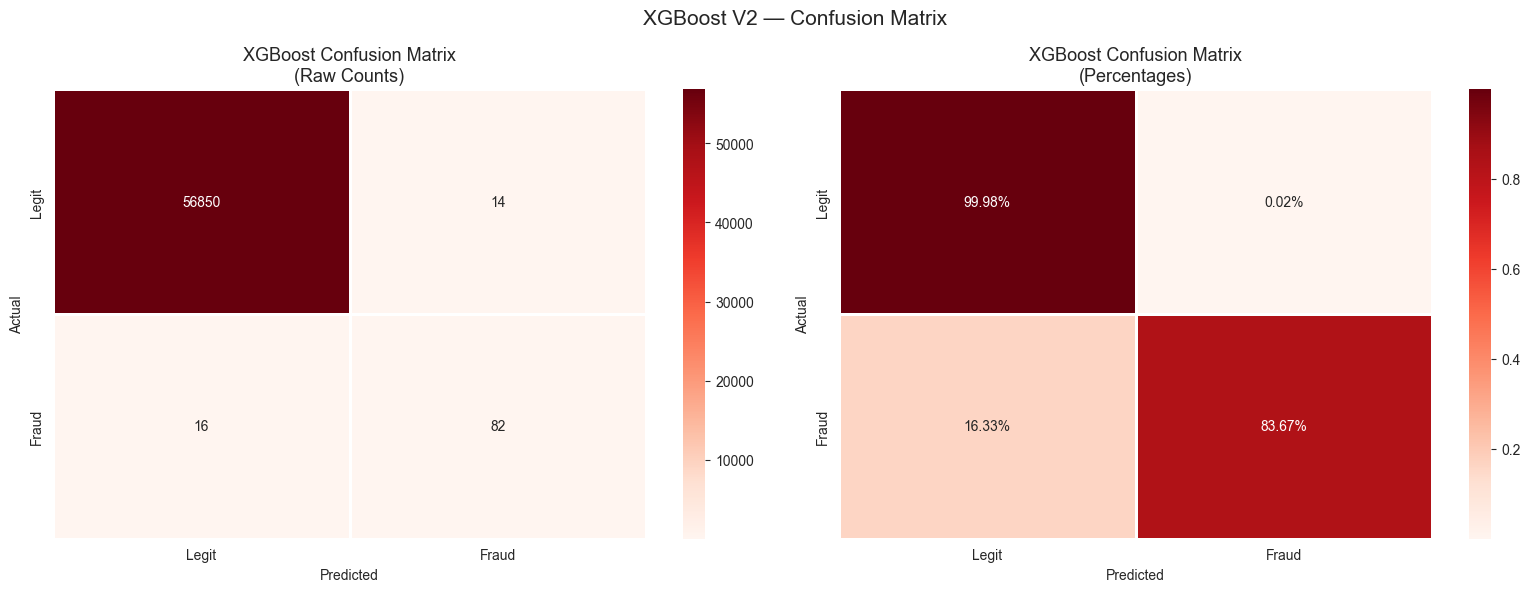


=== CONFUSION MATRIX BREAKDOWN ===
✅ Fraud Caught (TP):          82
❌ Fraud Missed (FN):          16
⚠️  False Alarms (FP):          14
✅ Legit Correct (TN):          56,850

🎯 Fraud Catch Rate: 83.7%
🎯 False Alarm Rate: 0.025%


In [33]:
# Cell 9 — Confusion Matrix
cm = confusion_matrix(y_test, y_pred_v2)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d',
            cmap='Reds',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'],
            ax=axes[0], linewidths=2)
axes[0].set_title('XGBoost Confusion Matrix\n(Raw Counts)',
                  fontsize=13)
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Percentages
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_pct, annot=True, fmt='.2%',
            cmap='Reds',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'],
            ax=axes[1], linewidths=2)
axes[1].set_title('XGBoost Confusion Matrix\n(Percentages)',
                  fontsize=13)
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.suptitle('XGBoost V2 — Confusion Matrix', fontsize=15)
plt.tight_layout()
plt.savefig('../data/xgb_confusion_matrix.png')
plt.show()

print(f"\n=== CONFUSION MATRIX BREAKDOWN ===")
print(f"✅ Fraud Caught (TP):          {tp}")
print(f"❌ Fraud Missed (FN):          {fn}")
print(f"⚠️  False Alarms (FP):          {fp:,}")
print(f"✅ Legit Correct (TN):          {tn:,}")
print(f"\n🎯 Fraud Catch Rate: {tp/(tp+fn)*100:.1f}%")
print(f"🎯 False Alarm Rate: {fp/(fp+tn)*100:.3f}%")

In [34]:
# Cell 10 — Side by side comparison
print("=" * 60)
print("XGBOOST vs LOGISTIC REGRESSION — COMPARISON")
print("=" * 60)

# Get LR metrics from baseline
lr_recall = baseline['classification_report']['Fraud']['recall']
lr_precision = baseline['classification_report']['Fraud']['precision']
lr_f1 = baseline['classification_report']['Fraud']['f1-score']
lr_auc = baseline['auc_roc']

# XGBoost metrics
from sklearn.metrics import precision_score, recall_score, f1_score
xgb_precision = precision_score(y_test, y_pred_v2)
xgb_recall = recall_score(y_test, y_pred_v2)
xgb_f1 = f1_score(y_test, y_pred_v2)
xgb_auc = roc_auc_score(y_test, y_prob_v2)

print(f"\n{'Metric':<25} {'Logistic Reg':>15} "
      f"{'XGBoost':>12} {'Improvement':>15}")
print("-" * 70)
print(f"{'AUC-ROC':<25} {lr_auc:>15.4f} "
      f"{xgb_auc:>12.4f} "
      f"{'+'+str(round(xgb_auc-lr_auc,4)):>15}")
print(f"{'Fraud Recall':<25} {lr_recall:>15.4f} "
      f"{xgb_recall:>12.4f} "
      f"{'+'+str(round(xgb_recall-lr_recall,4)):>15}")
print(f"{'Fraud Precision':<25} {lr_precision:>15.4f} "
      f"{xgb_precision:>12.4f} "
      f"{'+'+str(round(xgb_precision-lr_precision,4)):>15}")
print(f"{'Fraud F1':<25} {lr_f1:>15.4f} "
      f"{xgb_f1:>12.4f} "
      f"{'+'+str(round(xgb_f1-lr_f1,4)):>15}")

XGBOOST vs LOGISTIC REGRESSION — COMPARISON

Metric                       Logistic Reg      XGBoost     Improvement
----------------------------------------------------------------------
AUC-ROC                            0.9707       0.9817          +0.011
Fraud Recall                       0.9082       0.8367        +-0.0714
Fraud Precision                    0.0551       0.8542         +0.7991
Fraud F1                           0.1039       0.8454         +0.7414


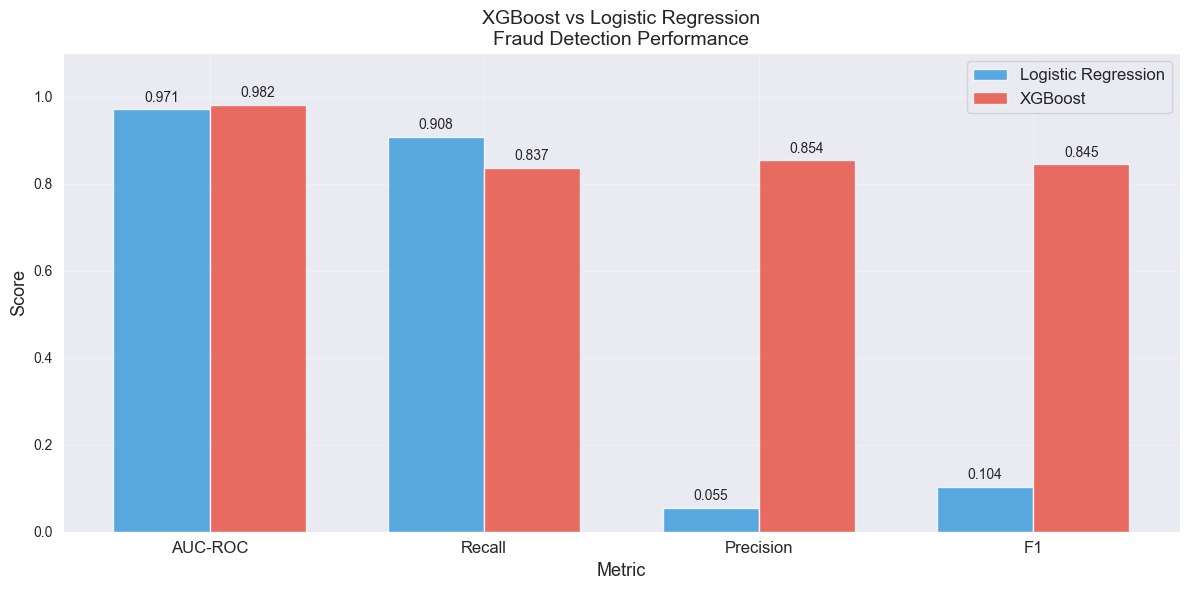

In [35]:
# Cell 11 — Visual comparison bar chart
metrics = ['AUC-ROC', 'Recall', 'Precision', 'F1']
lr_scores = [lr_auc, lr_recall, lr_precision, lr_f1]
xgb_scores = [xgb_auc, xgb_recall, xgb_precision, xgb_f1]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width/2, lr_scores, width,
               label='Logistic Regression',
               color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, xgb_scores, width,
               label='XGBoost',
               color='#e74c3c', alpha=0.8)

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2.,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=10)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2.,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Metric', fontsize=13)
ax.set_ylabel('Score', fontsize=13)
ax.set_title('XGBoost vs Logistic Regression\n'
             'Fraud Detection Performance',
             fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.legend(fontsize=12)
ax.set_ylim([0, 1.1])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/xgb_vs_lr_comparison.png')
plt.show()

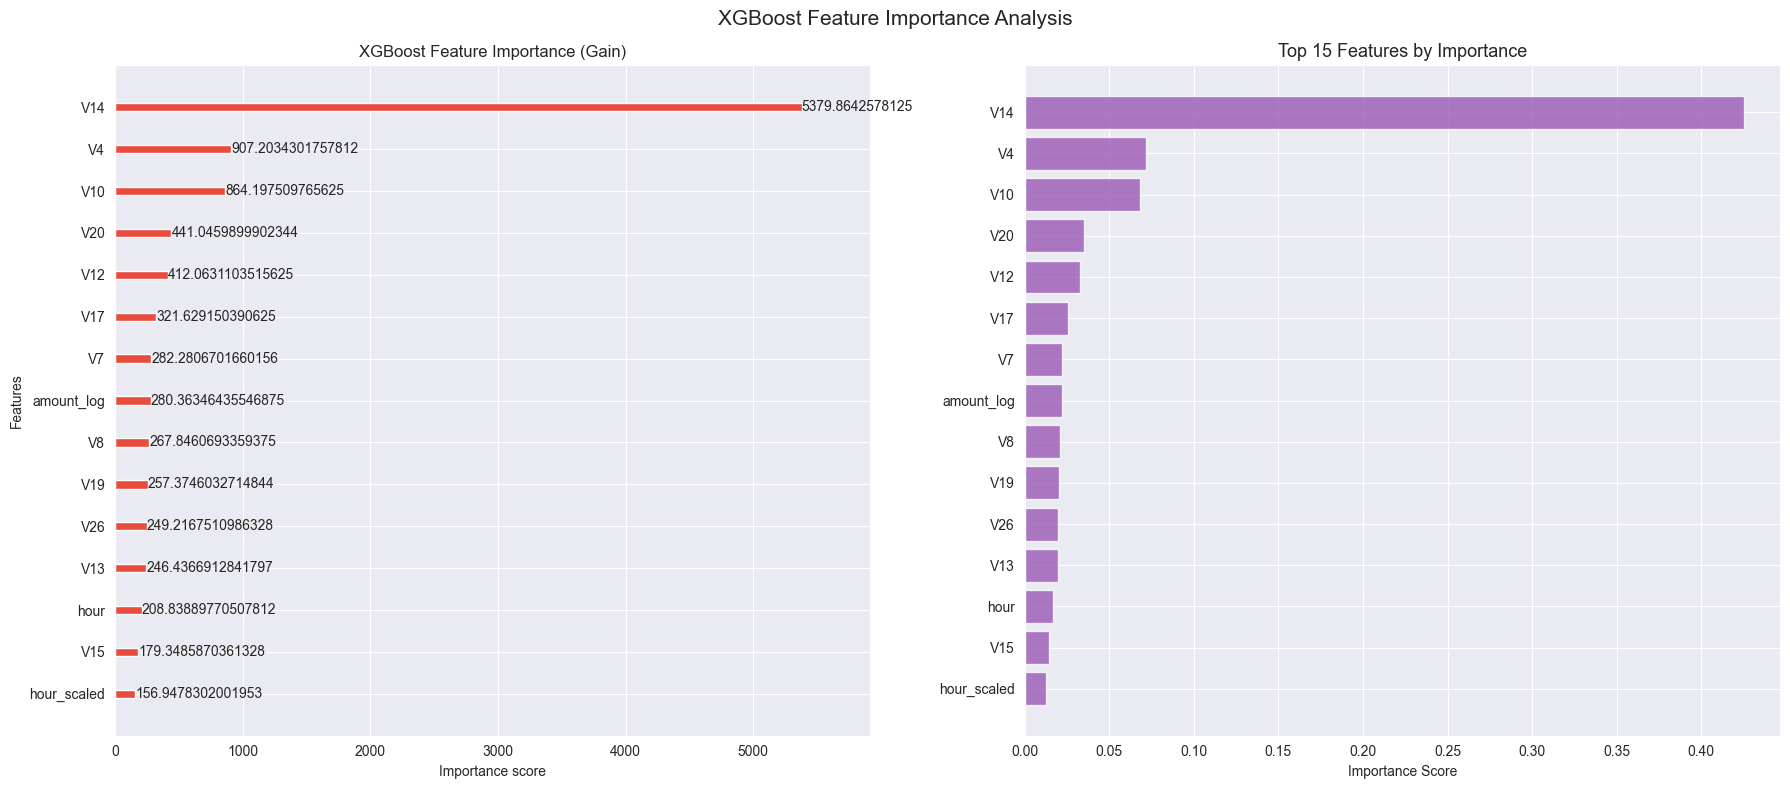

=== TOP 10 MOST IMPORTANT FEATURES ===
   Feature  Importance
       V14    0.425290
        V4    0.071716
       V10    0.068317
       V20    0.034866
       V12    0.032575
       V17    0.025426
        V7    0.022315
amount_log    0.022163
        V8    0.021174
       V19    0.020346

✅ V14, V17 should be at the top — matches our EDA!


In [36]:
# Cell 12 — Feature Importance Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Method 1: Built-in XGBoost importance
plot_importance(xgb_v2, ax=axes[0],
                max_num_features=15,
                importance_type='gain',
                color='#e74c3c',
                title='XGBoost Feature Importance (Gain)')

# Method 2: Custom sorted bar chart
importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': xgb_v2.feature_importances_
}).sort_values('Importance', ascending=True).tail(15)

axes[1].barh(importance_df['Feature'],
             importance_df['Importance'],
             color='#9b59b6', alpha=0.8)
axes[1].set_title('Top 15 Features by Importance',
                  fontsize=13)
axes[1].set_xlabel('Importance Score')

plt.suptitle('XGBoost Feature Importance Analysis',
             fontsize=15)
plt.tight_layout()
plt.savefig('../data/xgb_feature_importance.png')
plt.show()

# Print top 10
print("=== TOP 10 MOST IMPORTANT FEATURES ===")
top10 = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': xgb_v2.feature_importances_
}).sort_values('Importance', ascending=False).head(10)
print(top10.to_string(index=False))
print("\n✅ V14, V17 should be at the top — matches our EDA!")

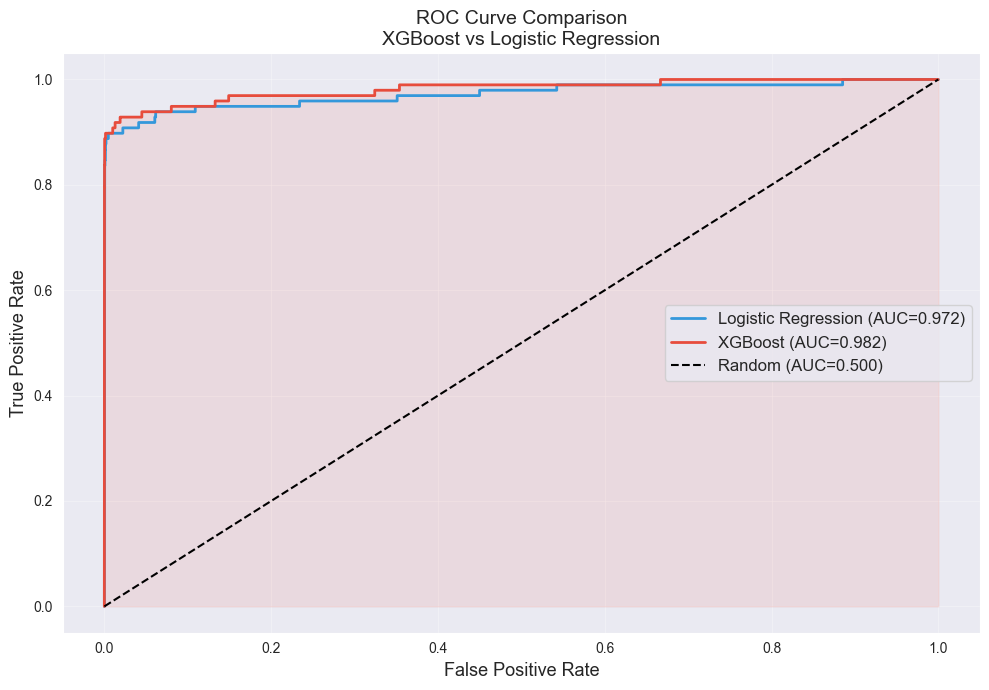

In [37]:
# Cell 13 — ROC curves for both models
import pickle

# Get LR probabilities
# (retrain quickly for comparison)
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42,
                        class_weight='balanced')
lr.fit(X_train_smote, y_train_smote)
lr_prob = lr.predict_proba(X_test)[:, 1]

# Calculate curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_v2)

auc_lr = roc_auc_score(y_test, lr_prob)
auc_xgb = roc_auc_score(y_test, y_prob_v2)

plt.figure(figsize=(10, 7))

plt.plot(fpr_lr, tpr_lr, color='#3498db', linewidth=2,
         label=f'Logistic Regression (AUC={auc_lr:.3f})')
plt.plot(fpr_xgb, tpr_xgb, color='#e74c3c', linewidth=2,
         label=f'XGBoost (AUC={auc_xgb:.3f})')
plt.plot([0,1], [0,1], 'k--', linewidth=1.5,
         label='Random (AUC=0.500)')

plt.fill_between(fpr_xgb, tpr_xgb, alpha=0.1,
                 color='#e74c3c')
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curve Comparison\nXGBoost vs Logistic Regression',
          fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/roc_comparison.png')
plt.show()

In [38]:
# Cell 14 — Save the model
with open('../models/xgb_fraud_model.pkl', 'wb') as f:
    pickle.dump(xgb_v2, f)

# Save XGBoost results
xgb_results = {
    'model': 'XGBoost V2',
    'auc_roc': round(float(xgb_auc), 4),
    'avg_precision': round(float(avg_prec), 4),
    'fraud_recall': round(float(xgb_recall), 4),
    'fraud_precision': round(float(xgb_precision), 4),
    'fraud_f1': round(float(xgb_f1), 4),
    'confusion_matrix': cm.tolist(),
    'params': xgb_v2.get_params()
}

with open('../models/xgb_results.json', 'w') as f:
    json.dump(xgb_results, f, indent=2)

print("✅ Model saved to models/xgb_fraud_model.pkl")
print("✅ Results saved to models/xgb_results.json")
print(f"\n=== FINAL RESULTS ===")
print(f"AUC-ROC:        {xgb_auc:.4f}")
print(f"Fraud Recall:   {xgb_recall:.4f}")
print(f"Fraud Precision:{xgb_precision:.4f}")
print(f"Fraud F1:       {xgb_f1:.4f}")

✅ Model saved to models/xgb_fraud_model.pkl
✅ Results saved to models/xgb_results.json

=== FINAL RESULTS ===
AUC-ROC:        0.9817
Fraud Recall:   0.8367
Fraud Precision:0.8542
Fraud F1:       0.8454
